# Neural ODE 学习未知动力学（对应书中 §4.6 / Algorithm 8）

$$\frac{dx}{dt} = f_\theta(x),\qquad
\min_\theta \sum_i \|x_\theta(t_i) - x^{\mathrm{data}}(t_i)\|^2$$

真实系统取 torchdiffeq 官方示例的三次螺旋：$\dot x = A\,x^3$，
$A=\begin{pmatrix}-0.1 & 2\\ -2 & -0.1\end{pmatrix}$。
这里用可微分 RK4 直接反传（discretize-then-optimize）；伴随法（Algorithm 8）
在需要常数内存时使用，两者梯度一致。

In [1]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

torch.manual_seed(0)

A = torch.tensor([[-0.1, 2.0], [-2.0, -0.1]])

def f_true(x):
    return (x ** 3) @ A.T

def rk4_traj(f, x0, dt, n):
    xs = [x0]
    x = x0
    for _ in range(n):
        k1 = f(x); k2 = f(x + dt / 2 * k1)
        k3 = f(x + dt / 2 * k2); k4 = f(x + dt * k3)
        x = x + dt / 6 * (k1 + 2 * k2 + 2 * k3 + k4)
        xs.append(x)
    return torch.stack(xs)

dt, N = 0.05, 200
x0 = torch.tensor([[2.0, 0.0]])
with torch.no_grad():
    data = rk4_traj(f_true, x0, dt, N).squeeze(1)     # (N+1, 2)

In [ ]:
f_net = nn.Sequential(
    nn.Linear(2, 64), nn.Tanh(),
    nn.Linear(64, 64), nn.Tanh(),
    nn.Linear(64, 2),
)
opt = torch.optim.Adam(f_net.parameters(), lr=2e-3)
sched = torch.optim.lr_scheduler.StepLR(opt, step_size=1500, gamma=0.3)

seg = 20   
for epoch in range(6001):
    i0 = torch.randint(0, N - seg, (32,))
    starts = data[i0]                                  # (32, 2)
    target = torch.stack([data[i0 + k] for k in range(seg + 1)])  # (seg+1, 32, 2)

    pred = rk4_traj(lambda x: f_net(x), starts, dt, seg)
    loss = ((pred - target) ** 2).mean()

    opt.zero_grad()
    loss.backward()
    opt.step()
    sched.step()
    if epoch % 500 == 0:
        print(f"epoch {epoch:5d}   loss = {loss.item():.3e}")

epoch     0   loss = 1.404e+00
epoch   500   loss = 1.635e-02
epoch  1000   loss = 6.754e-03
epoch  1500   loss = 6.885e-03
epoch  2000   loss = 3.281e-03
epoch  2500   loss = 4.449e-04


epoch   500   loss = 2.437e-02


epoch  1000   loss = 3.172e-03


epoch  1500   loss = 1.016e-03


epoch  2000   loss = 6.518e-04


epoch  2500   loss = 4.973e-04


epoch  3000   loss = 5.814e-04


epoch  3500   loss = 1.843e-04


epoch  4000   loss = 1.331e-04


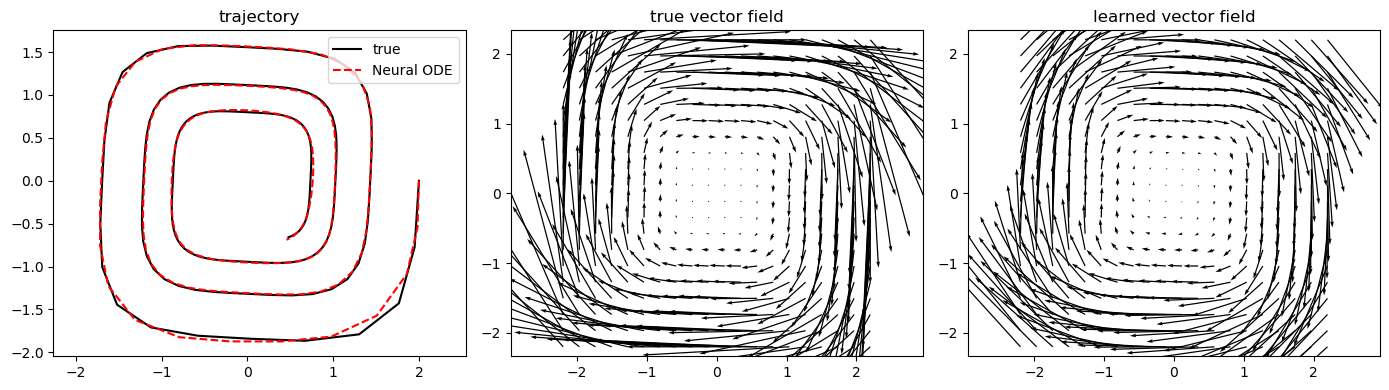

轨迹最大误差: 0.3726547956466675


In [3]:
with torch.no_grad():
    pred_traj = rk4_traj(lambda x: f_net(x), x0, dt, N).squeeze(1)

    g = torch.linspace(-2.2, 2.2, 20)
    XX, YY = torch.meshgrid(g, g, indexing="xy")
    P = torch.stack([XX.flatten(), YY.flatten()], dim=1)
    V_true, V_net = f_true(P), f_net(P)

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
axes[0].plot(data[:, 0], data[:, 1], "k-", label="true")
axes[0].plot(pred_traj[:, 0], pred_traj[:, 1], "r--", label="Neural ODE")
axes[0].set_title("trajectory"); axes[0].legend(); axes[0].axis("equal")
for ax, V, title in [(axes[1], V_true, "true vector field"),
                     (axes[2], V_net, "learned vector field")]:
    ax.quiver(P[:, 0], P[:, 1], V[:, 0], V[:, 1], scale=60, width=0.003)
    ax.set_title(title); ax.axis("equal")
plt.tight_layout(); plt.show()

print("轨迹最大误差:", (pred_traj - data).abs().max().item())